# San Antonio Revenue & Fund Allocation — Comprehensive Analysis

Where does the city's money come from, and how does it flow across funds?

**Data:** Scraped from 27 adopted budget PDFs (FY 2008–2026) via `src/scrape_budgets.py`

Three main datasets:
- `combined_budget_summary.csv` — high-level revenue & appropriation by fund (General Fund, Total All Funds)
- `all_funds_revenue.csv` — granular revenue by source and fund type (General, Enterprise, Special Revenue, Trust, Internal Service)
- `general_fund_departments.csv` — department-level appropriations (how revenue gets spent)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data/processed/'

combined = pd.read_csv(f'{DATA_DIR}combined_budget_summary.csv')
revenue = pd.read_csv(f'{DATA_DIR}all_funds_revenue.csv')
depts = pd.read_csv(f'{DATA_DIR}general_fund_departments.csv')

# Normalize fund name casing
fund_fixes = {
    'GENERAL FUND': 'General Fund',
    'ENTERPRISE FUNDS': 'Enterprise Funds',
    'SPECIAL REVENUE FUNDS': 'Special Revenue Funds',
    'TRUST FUNDS': 'Trust Funds',
    'TRUST FUND': 'Trust Funds',
    'INTERNAL SERVICE FUNDS': 'Internal Service Funds',
    'OTHER FUNDS': 'Other Funds',
}
revenue['fund'] = revenue['fund'].replace(fund_fixes)

print(f'Combined summary: {len(combined)} rows, FY {combined.fiscal_year.min()}–{combined.fiscal_year.max()}')
print(f'All Funds Revenue: {len(revenue)} rows, FY {revenue.fiscal_year.min()}–{revenue.fiscal_year.max()}')
print(f'Departments:       {len(depts)} rows, FY {depts.fiscal_year.min()}–{depts.fiscal_year.max()}')
print(f'\nFund types: {sorted(revenue.fund.unique())}')

Combined summary: 1162 rows, FY 2008–2026
All Funds Revenue: 1497 rows, FY 2008–2026
Departments:       1143 rows, FY 2008–2026

Fund types: ['Enterprise Funds', 'General Fund', 'Internal Service Funds', 'Other Funds', 'Special Revenue Funds', 'Trust Funds']


## 1. The Big Picture — Total City Revenue Over Time

SA's total budget spans the General Fund (the city's main operating account) plus Enterprise Funds
(airport, solid waste, etc.), Special Revenue Funds (Pre-K 4 SA, TIF districts), and others.

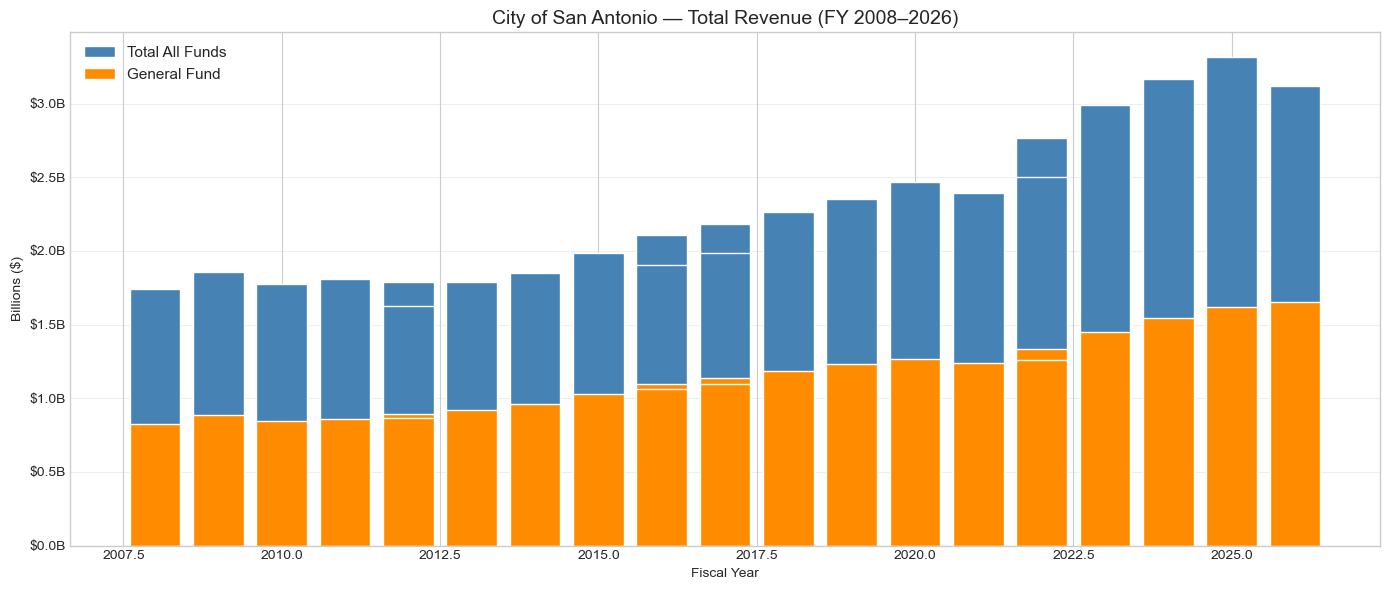

FY 2026 Total Revenue:        $3.12B
FY 2026 General Fund Revenue: $1.65B (53% of total)

Growth (FY 2008→2026): 2.0x


In [2]:
# Extract total revenue lines from combined summary
total_rev_all = combined[
    (combined['fund'] == 'Total All Funds') &
    (combined['line_item'].str.contains('TOTAL REVENUES', case=False))
].sort_values('fiscal_year')

total_rev_gf = combined[
    (combined['fund'] == 'General Fund') &
    (combined['line_item'].str.contains('TOTAL REVENUES', case=False))
].sort_values('fiscal_year')

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(total_rev_all['fiscal_year'], total_rev_all['amount'] / 1e9,
       color='steelblue', edgecolor='white', label='Total All Funds')
ax.bar(total_rev_gf['fiscal_year'], total_rev_gf['amount'] / 1e9,
       color='darkorange', edgecolor='white', label='General Fund')

ax.set_title('City of San Antonio — Total Revenue (FY 2008–2026)', fontsize=14)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Billions ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.1f}B'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

gf_share = total_rev_gf['amount'].values[-1] / total_rev_all['amount'].values[-1]
print(f'FY 2026 Total Revenue:        ${total_rev_all["amount"].values[-1]/1e9:.2f}B')
print(f'FY 2026 General Fund Revenue: ${total_rev_gf["amount"].values[-1]/1e9:.2f}B ({gf_share:.0%} of total)')
print(f'\nGrowth (FY 2008→2026): {total_rev_all["amount"].values[-1]/total_rev_all["amount"].values[0]:.1f}x')

## 2. Where Does the Money Come From? — General Fund Revenue Sources

The General Fund is the city's main operating account. It's funded by a mix of
property tax, sales tax, utility transfers (CPS Energy, SAWS), fees, and fines.

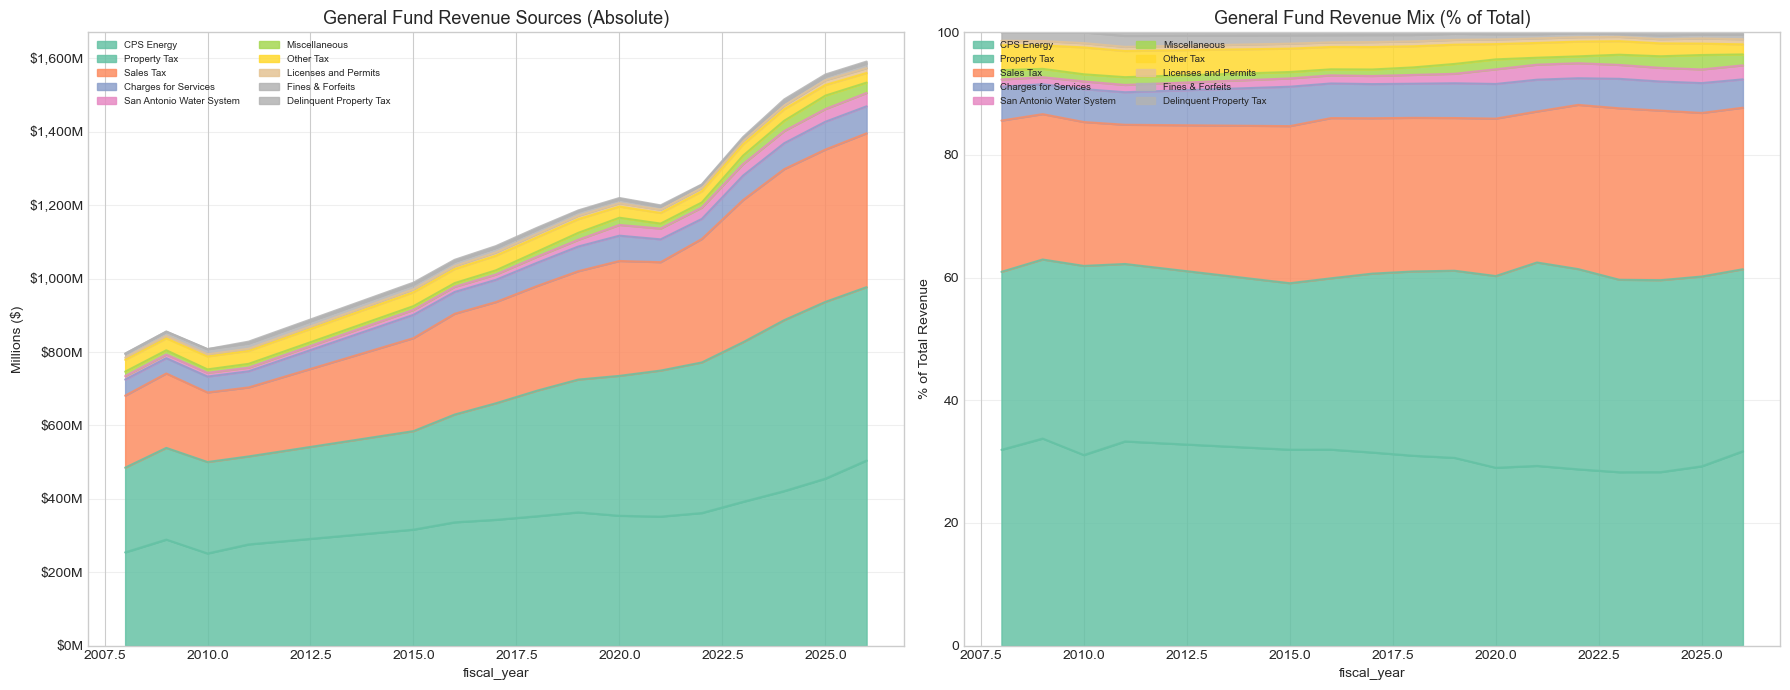

FY 2026 General Fund Revenue Breakdown:
  CPS Energy                     $     504M  (31.7%)
  Property Tax                   $     472M  (29.7%)
  Sales Tax                      $     419M  (26.3%)
  Charges for Services           $      74M  ( 4.6%)
  San Antonio Water System       $      36M  ( 2.3%)
  Miscellaneous                  $      28M  ( 1.8%)
  Other Tax                      $      26M  ( 1.6%)
  Licenses and Permits           $      13M  ( 0.8%)
  Fines & Forfeits               $      12M  ( 0.8%)
  Delinquent Property Tax        $       5M  ( 0.3%)


In [3]:
# General Fund revenue from the combined summary (clean, high-level categories)
gf_rev = combined[
    (combined['fund'] == 'General Fund') &
    (combined['section'] == 'revenue') &
    (~combined['line_item'].str.contains('Subtotal|TOTAL|Transfer', case=False, na=False))
].copy()
gf_rev['line_item'] = gf_rev['line_item'].replace({'Fines and Forfeits': 'Fines & Forfeits'})

rev_pivot = gf_rev.pivot_table(index='fiscal_year', columns='line_item', values='amount', aggfunc='first')

# Order by FY 2026 size
latest = rev_pivot.iloc[-1].sort_values(ascending=False)
rev_pivot = rev_pivot[latest.index]

# Stacked area
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = plt.cm.Set2(np.linspace(0, 1, len(rev_pivot.columns)))
(rev_pivot / 1e6).plot.area(ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title('General Fund Revenue Sources (Absolute)', fontsize=13)
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(loc='upper left', fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

# Percentage
rev_pct = rev_pivot.div(rev_pivot.sum(axis=1), axis=0) * 100
rev_pct.plot.area(ax=axes[1], color=colors, alpha=0.85)
axes[1].set_title('General Fund Revenue Mix (% of Total)', fontsize=13)
axes[1].set_ylabel('% of Total Revenue')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print FY 2026 breakdown
print('FY 2026 General Fund Revenue Breakdown:')
for col in rev_pivot.columns:
    val = rev_pivot[col].iloc[-1]
    if pd.notna(val) and val > 0:
        pct = val / rev_pivot.iloc[-1].sum() * 100
        print(f'  {col:30s} ${val/1e6:>8,.0f}M  ({pct:4.1f}%)')

## 3. The Three Revenue Pillars — Property Tax, Sales Tax, CPS Energy

These three sources fund ~85% of the General Fund. Let's see how they've tracked each other.

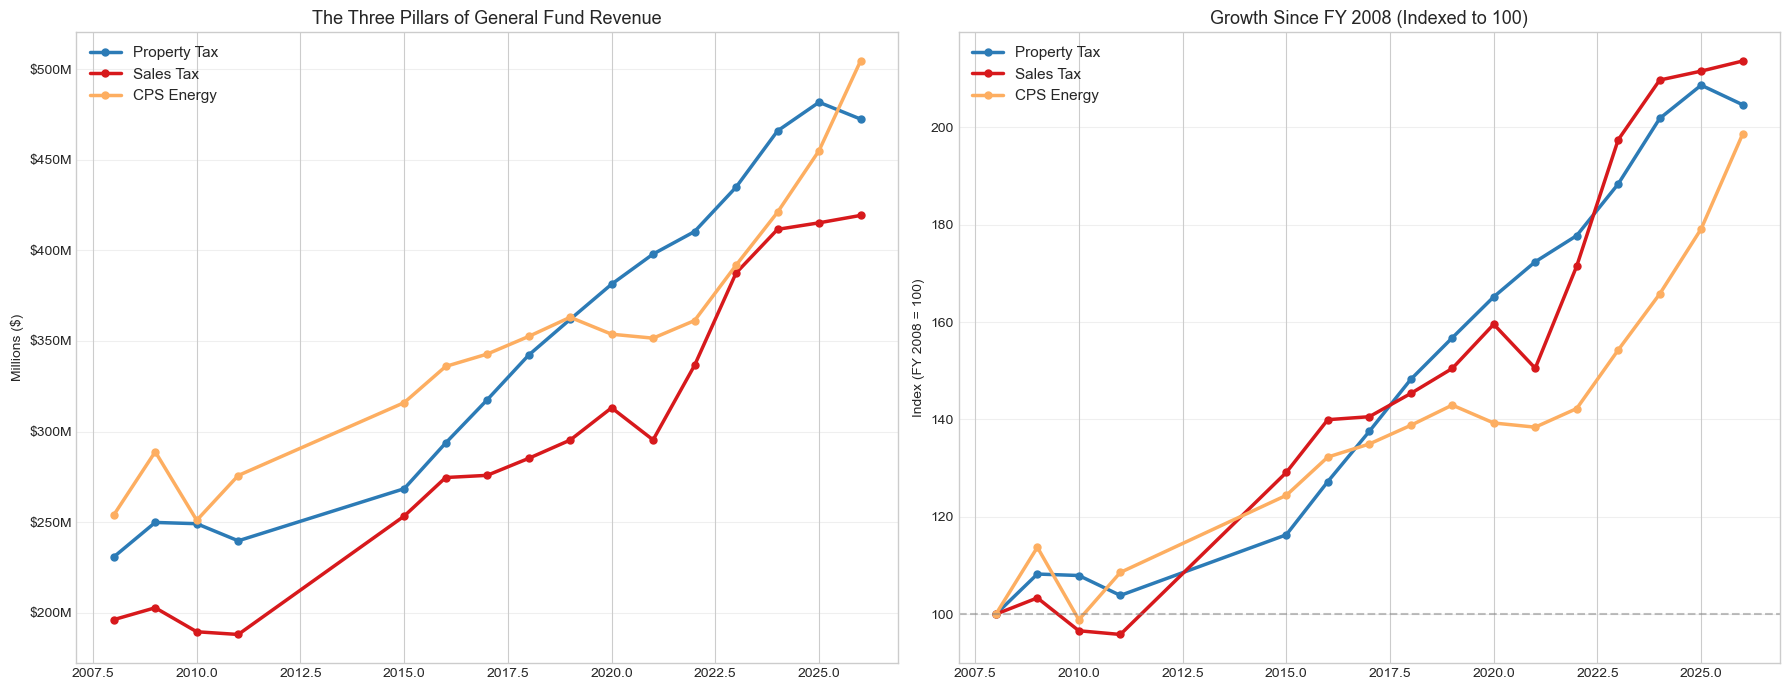

Property Tax: $231M → $472M (2.0x)
Sales Tax: $196M → $419M (2.1x)
CPS Energy: $254M → $504M (2.0x)


In [4]:
pillars = ['Property Tax', 'Sales Tax', 'CPS Energy']
pillar_colors = {'Property Tax': '#2c7bb6', 'Sales Tax': '#d7191c', 'CPS Energy': '#fdae61'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute
for col in pillars:
    data = rev_pivot[col].dropna()
    axes[0].plot(data.index, data / 1e6, 'o-', color=pillar_colors[col],
                 linewidth=2.5, markersize=5, label=col)

axes[0].set_title('The Three Pillars of General Fund Revenue', fontsize=13)
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Indexed growth (base year = first available)
for col in pillars:
    data = rev_pivot[col].dropna()
    indexed = data / data.iloc[0] * 100
    axes[1].plot(indexed.index, indexed, 'o-', color=pillar_colors[col],
                 linewidth=2.5, markersize=5, label=col)

axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Growth Since FY 2008 (Indexed to 100)', fontsize=13)
axes[1].set_ylabel('Index (FY 2008 = 100)')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for col in pillars:
    data = rev_pivot[col].dropna()
    print(f'{col}: ${data.iloc[0]/1e6:,.0f}M → ${data.iloc[-1]/1e6:,.0f}M ({data.iloc[-1]/data.iloc[0]:.1f}x)')

## 4. Revenue by Fund Type — Beyond the General Fund

The granular `all_funds_revenue.csv` dataset breaks revenue down by fund type:
General Fund, Enterprise Funds (airport, solid waste), Special Revenue, Trust, and Internal Service.

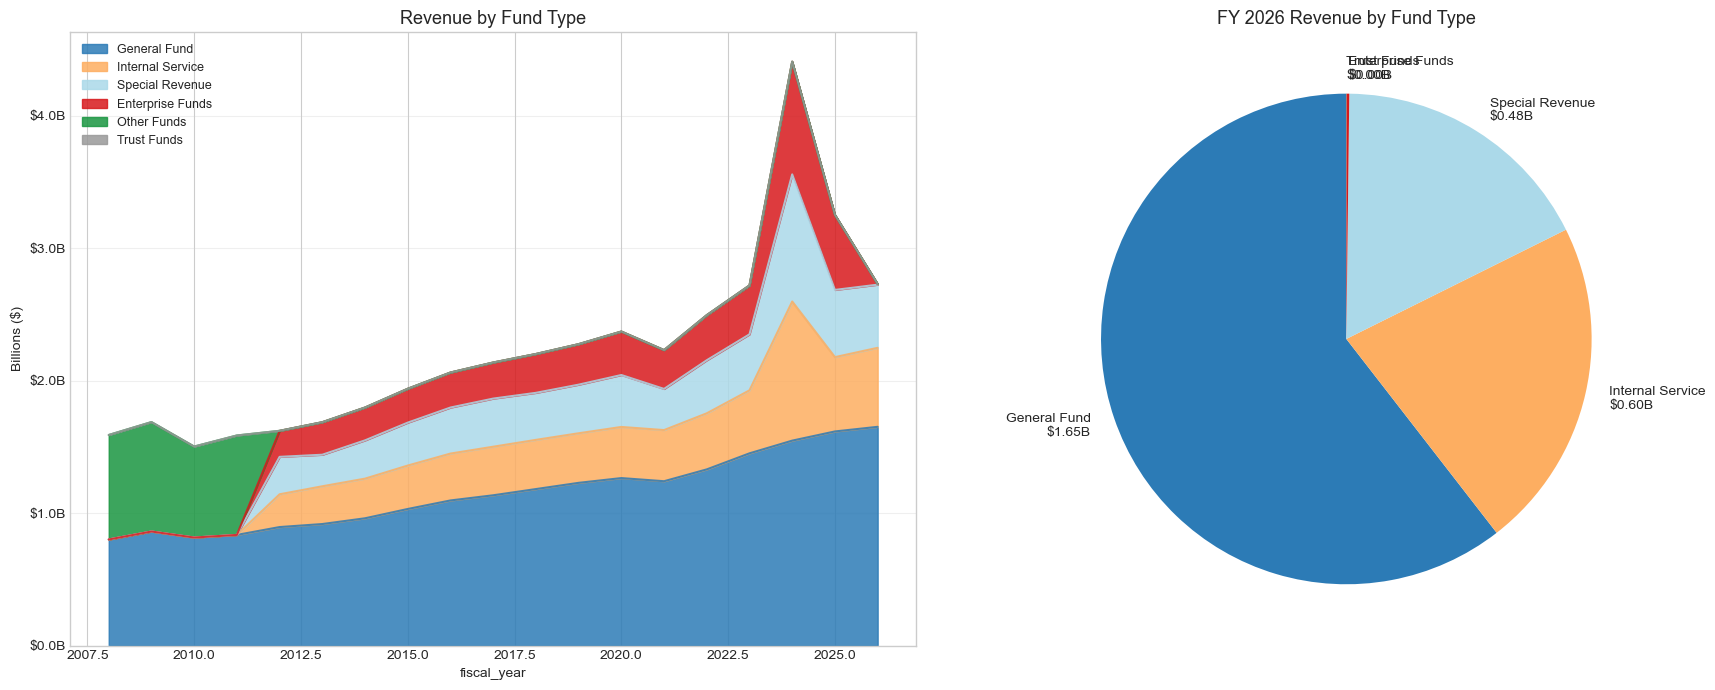

In [5]:
# Filter to TOTAL rows for each fund type (not individual line items)
fund_totals = revenue[
    revenue['line_item'].str.contains(r'^TOTAL\b', case=False, na=False)
].copy()

# Simplify fund labels from the TOTAL line_items
def extract_fund_label(row):
    li = row['line_item'].upper()
    if 'GENERAL' in li:
        return 'General Fund'
    elif 'ENTERPRISE' in li:
        return 'Enterprise Funds'
    elif 'SPECIAL' in li:
        return 'Special Revenue'
    elif 'TRUST' in li:
        return 'Trust Funds'
    elif 'INTERNAL' in li:
        return 'Internal Service'
    elif 'OTHER' in li:
        return 'Other Funds'
    elif 'ALL FUNDS' in li or 'TOTAL REVENUE' in li:
        return '_Grand Total'
    else:
        return row['fund']

fund_totals['fund_label'] = fund_totals.apply(extract_fund_label, axis=1)

# Drop grand total and pivot
fund_totals = fund_totals[fund_totals['fund_label'] != '_Grand Total']
fund_pivot = fund_totals.pivot_table(
    index='fiscal_year', columns='fund_label', values='adopted_amount', aggfunc='sum', fill_value=0
)

# Order by total
fund_pivot = fund_pivot[fund_pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#2c7bb6', '#fdae61', '#abd9e9', '#d7191c', '#1a9641', '#999999']

(fund_pivot / 1e9).plot.area(ax=axes[0], color=colors, alpha=0.85)
axes[0].set_title('Revenue by Fund Type', fontsize=13)
axes[0].set_ylabel('Billions ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.1f}B'))
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Latest year pie
latest_year = fund_pivot.index.max()
latest_vals = fund_pivot.loc[latest_year]
latest_vals = latest_vals[latest_vals > 0]
axes[1].pie(latest_vals,
            labels=[f'{k}\n${v/1e9:.2f}B' for k, v in latest_vals.items()],
            colors=colors[:len(latest_vals)], startangle=90)
axes[1].set_title(f'FY {latest_year} Revenue by Fund Type', fontsize=13)

plt.tight_layout()
plt.show()

## 5. Inside the Enterprise Funds — Airport, Solid Waste & More

Enterprise Funds are self-supporting — they're funded by user fees and charges,
not taxes. The airport, solid waste, parking, and golf course each run as a separate fund.

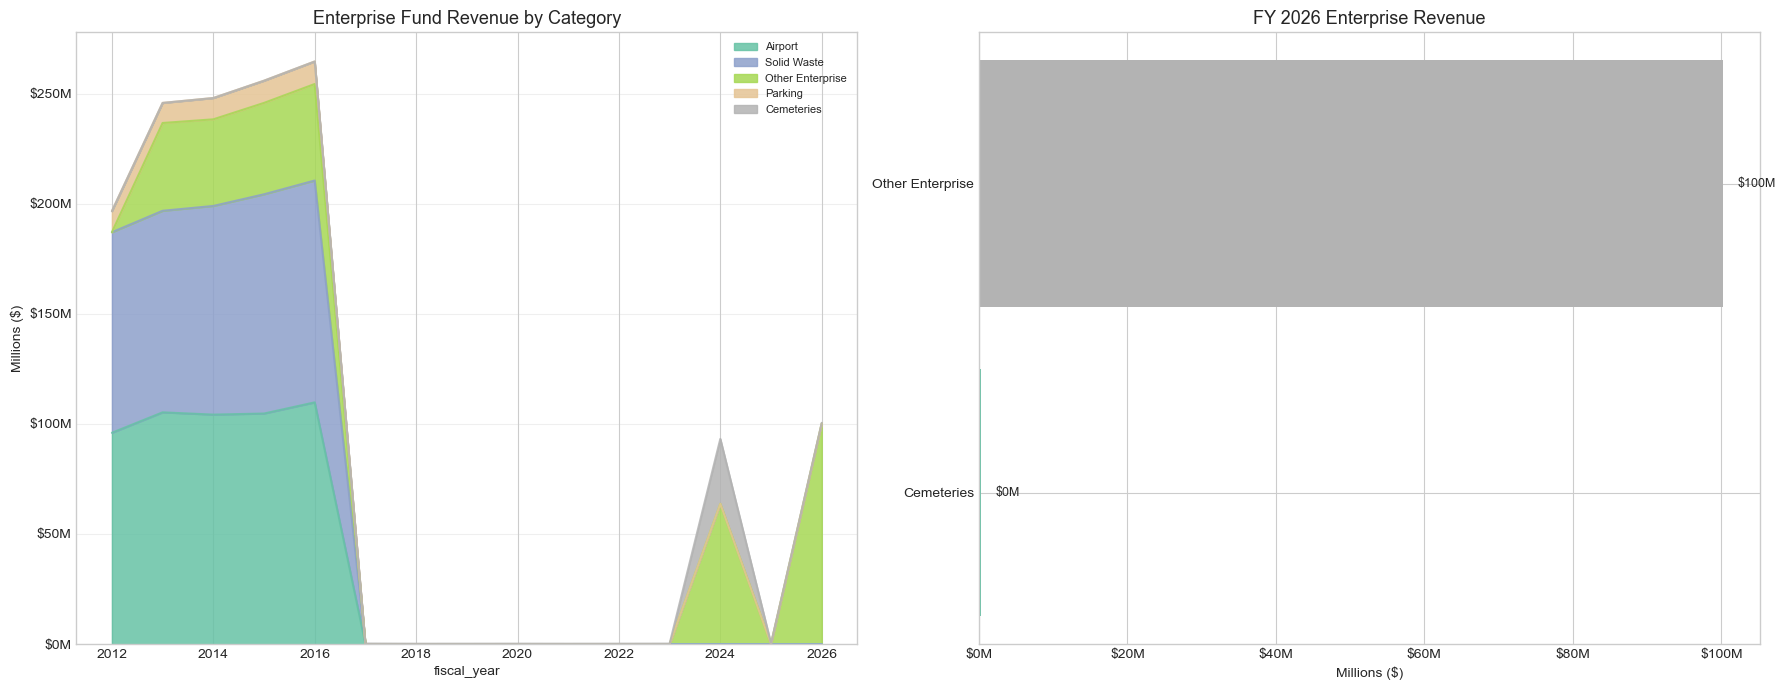

In [6]:
# Enterprise fund line items (non-total)
enterprise = revenue[
    (revenue['fund'] == 'Enterprise Funds') &
    (~revenue['line_item'].str.contains('TOTAL|Subtotal', case=False, na=False))
].copy()

# Group by major enterprise category
def classify_enterprise(li):
    li_lower = li.lower()
    if 'airport' in li_lower or 'aviation' in li_lower or 'terminal' in li_lower or 'passenger facility' in li_lower:
        return 'Airport'
    elif 'solid waste' in li_lower:
        return 'Solid Waste'
    elif 'storm' in li_lower:
        return 'Storm Water'
    elif 'parking' in li_lower:
        return 'Parking'
    elif 'golf' in li_lower:
        return 'Golf Course'
    elif 'riverwalk' in li_lower or 'river walk' in li_lower:
        return 'Riverwalk'
    elif 'cemeter' in li_lower:
        return 'Cemeteries'
    else:
        return 'Other Enterprise'

enterprise['category'] = enterprise['line_item'].apply(classify_enterprise)

ent_pivot = enterprise.pivot_table(
    index='fiscal_year', columns='category', values='adopted_amount', aggfunc='sum', fill_value=0
)
ent_pivot = ent_pivot[ent_pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

(ent_pivot / 1e6).plot.area(ax=axes[0], colormap='Set2', alpha=0.85)
axes[0].set_title('Enterprise Fund Revenue by Category', fontsize=13)
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Latest year breakdown
latest_ent = ent_pivot.loc[ent_pivot.index.max()]
latest_ent = latest_ent[latest_ent > 0].sort_values(ascending=True)
axes[1].barh(latest_ent.index, latest_ent / 1e6, color=plt.cm.Set2(np.linspace(0, 1, len(latest_ent))))
axes[1].set_xlabel('Millions ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[1].set_title(f'FY {ent_pivot.index.max()} Enterprise Revenue', fontsize=13)
for i, (cat, val) in enumerate(latest_ent.items()):
    axes[1].text(val / 1e6 + 2, i, f'${val/1e6:,.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Special Revenue Funds — Voter-Mandated & Earmarked Programs

Special Revenue Funds capture money earmarked for specific purposes:
Pre-K 4 SA (funded by 1/8-cent sales tax), Tax Increment Financing districts, and other dedicated programs.

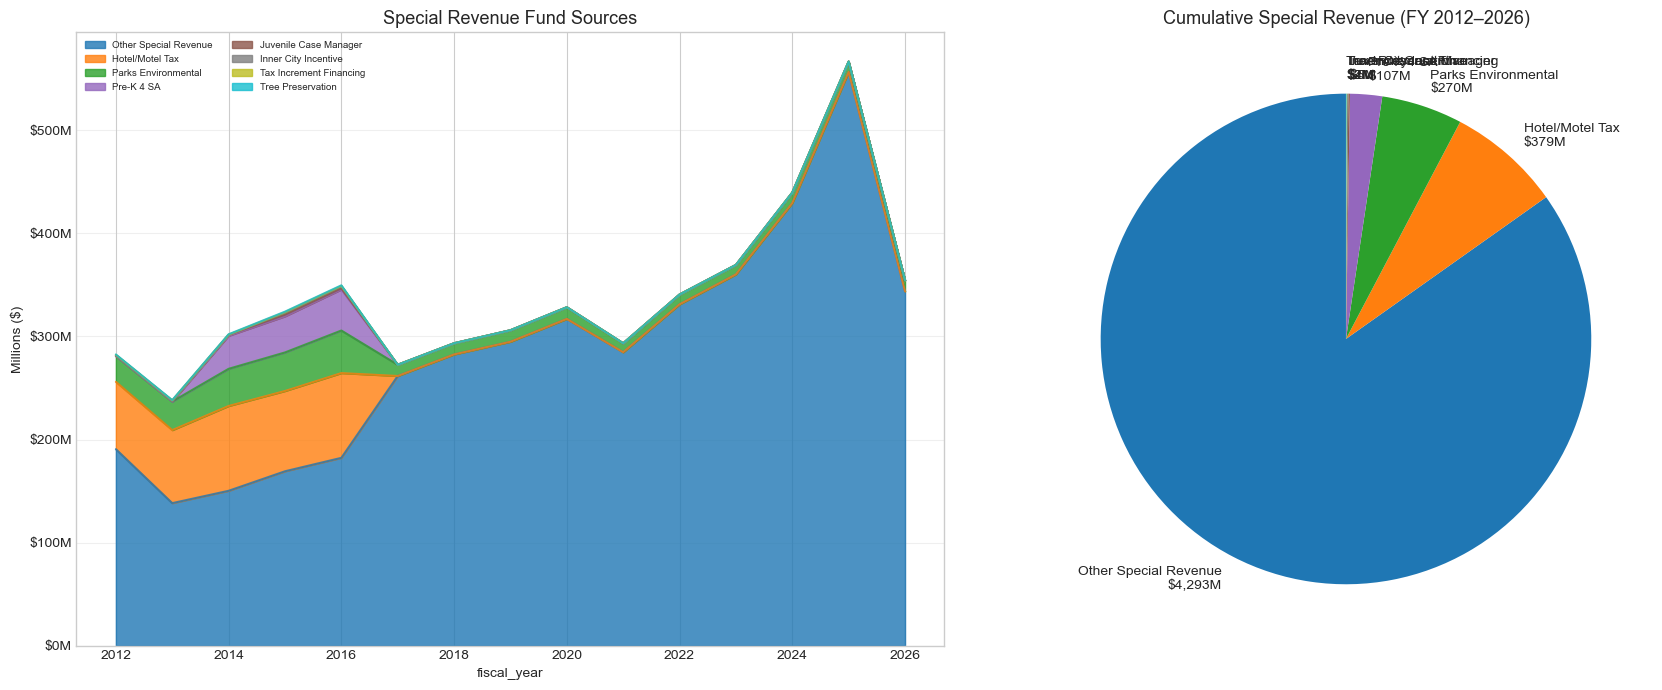

In [7]:
special = revenue[
    (revenue['fund'] == 'Special Revenue Funds') &
    (~revenue['line_item'].str.contains('TOTAL|Subtotal', case=False, na=False))
].copy()

def classify_special(li):
    li_lower = li.lower()
    if 'pre-k' in li_lower or 'prek' in li_lower:
        return 'Pre-K 4 SA'
    elif 'tax increment' in li_lower or 'tif' in li_lower or 'tirz' in li_lower:
        return 'Tax Increment Financing'
    elif 'hotel' in li_lower or 'motel' in li_lower or 'hom' in li_lower:
        return 'Hotel/Motel Tax'
    elif 'grant' in li_lower:
        return 'Grants'
    elif 'juvenile' in li_lower:
        return 'Juvenile Case Manager'
    elif 'tree' in li_lower or 'canopy' in li_lower:
        return 'Tree Preservation'
    elif 'park' in li_lower or 'environmental' in li_lower:
        return 'Parks Environmental'
    elif 'street' in li_lower or 'endowment' in li_lower:
        return 'Streets Endowment'
    elif 'inner city' in li_lower:
        return 'Inner City Incentive'
    else:
        return 'Other Special Revenue'

special['category'] = special['line_item'].apply(classify_special)

spec_pivot = special.pivot_table(
    index='fiscal_year', columns='category', values='adopted_amount', aggfunc='sum', fill_value=0
)
spec_pivot = spec_pivot[spec_pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

(spec_pivot / 1e6).plot.area(ax=axes[0], colormap='tab10', alpha=0.8)
axes[0].set_title('Special Revenue Fund Sources', fontsize=13)
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(loc='upper left', fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

# Cumulative pie
spec_totals = spec_pivot.sum().sort_values(ascending=False)
spec_totals = spec_totals[spec_totals > 0]
axes[1].pie(spec_totals,
            labels=[f'{k}\n${v/1e6:,.0f}M' for k, v in spec_totals.items()],
            colors=plt.cm.tab10(np.linspace(0, 1, len(spec_totals))),
            startangle=90)
axes[1].set_title(f'Cumulative Special Revenue (FY {special.fiscal_year.min()}–{special.fiscal_year.max()})', fontsize=13)

plt.tight_layout()
plt.show()

## 7. Revenue vs. Appropriations — Is SA Running Balanced Budgets?

Texas law requires balanced budgets for cities. Let's check how tightly revenue and
spending track each other — both for the General Fund and Total All Funds.

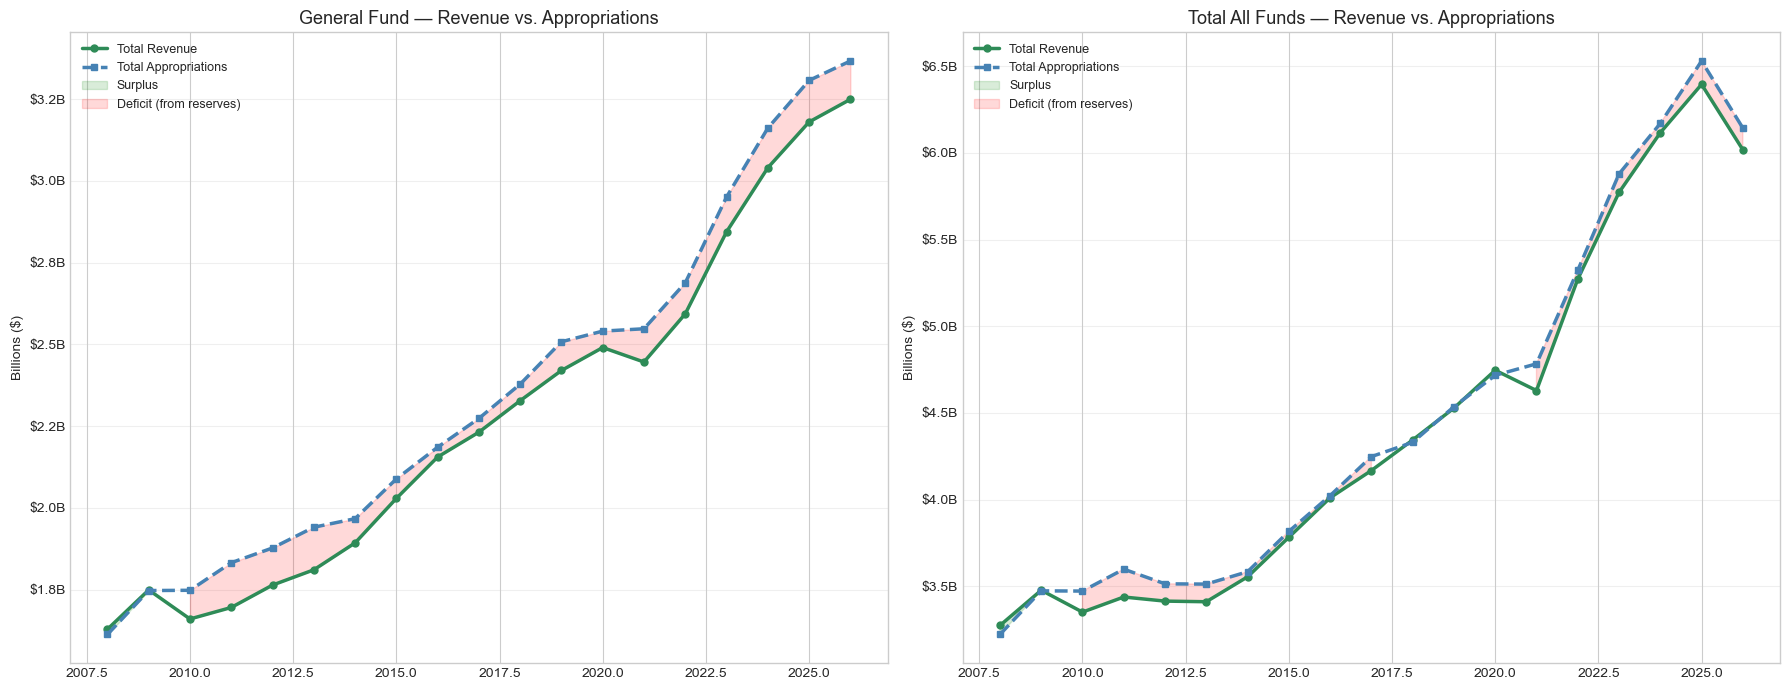

FY 2008: Revenue $1.63B − Appropriations $1.61B = $+16M (surplus)
FY 2009: Revenue $1.75B − Appropriations $1.75B = $+2M (surplus)
FY 2010: Revenue $1.66B − Appropriations $1.75B = $-88M (deficit)
FY 2011: Revenue $1.70B − Appropriations $1.83B = $-137M (deficit)
FY 2012: Revenue $1.76B − Appropriations $1.88B = $-113M (deficit)
FY 2013: Revenue $1.81B − Appropriations $1.94B = $-130M (deficit)
FY 2014: Revenue $1.89B − Appropriations $1.97B = $-74M (deficit)
FY 2015: Revenue $2.03B − Appropriations $2.09B = $-60M (deficit)
FY 2016: Revenue $2.16B − Appropriations $2.19B = $-30M (deficit)
FY 2017: Revenue $2.23B − Appropriations $2.27B = $-42M (deficit)
FY 2018: Revenue $2.33B − Appropriations $2.38B = $-51M (deficit)
FY 2019: Revenue $2.42B − Appropriations $2.51B = $-88M (deficit)
FY 2020: Revenue $2.49B − Appropriations $2.54B = $-50M (deficit)
FY 2021: Revenue $2.45B − Appropriations $2.55B = $-102M (deficit)
FY 2022: Revenue $2.59B − Appropriations $2.69B = $-95M (deficit)
FY 2023

In [10]:
# Build revenue vs appropriation comparison
def get_totals(fund, line_pattern):
    return combined[
        (combined['fund'] == fund) &
        (combined['line_item'].str.contains(line_pattern, case=False))
    ].groupby('fiscal_year')['amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (fund, title) in enumerate([('General Fund', 'General Fund'), ('Total All Funds', 'Total All Funds')]):
    rev = get_totals(fund, 'TOTAL REVENUES').sort_index()
    app = get_totals(fund, 'TOTAL APPROPRIATIONS').sort_index()

    axes[i].plot(rev.index, rev / 1e9, 'o-', color='seagreen', linewidth=2.5, markersize=5, label='Total Revenue')
    axes[i].plot(app.index, app / 1e9, 's--', color='steelblue', linewidth=2.5, markersize=5, label='Total Appropriations')

    # Shade surplus/deficit
    common = rev.index.intersection(app.index)
    axes[i].fill_between(common, rev.loc[common] / 1e9, app.loc[common] / 1e9,
                         where=(rev.loc[common] >= app.loc[common]),
                         alpha=0.15, color='green', label='Surplus')
    axes[i].fill_between(common, rev.loc[common] / 1e9, app.loc[common] / 1e9,
                         where=(rev.loc[common] < app.loc[common]),
                         alpha=0.15, color='red', label='Deficit (from reserves)')

    axes[i].set_title(f'{title} — Revenue vs. Appropriations', fontsize=13)
    axes[i].set_ylabel('Billions ($)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.1f}B'))
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the gap
rev_latest = get_totals('General Fund', 'TOTAL REVENUES')
app_latest = get_totals('General Fund', 'TOTAL APPROPRIATIONS')
for fy in sorted(rev_latest.index.intersection(app_latest.index)):
    gap = rev_latest.loc[fy] - app_latest.loc[fy]
    label = 'surplus' if gap >= 0 else 'deficit'
    print(f'FY {fy}: Revenue ${rev_latest.loc[fy]/1e9:.2f}B − Appropriations ${app_latest.loc[fy]/1e9:.2f}B = ${gap/1e6:+,.0f}M ({label})')

## 8. CPS Energy — The City's Unique Revenue Engine

CPS Energy (the municipally-owned electric utility) transfers revenue to the city's General Fund.
This is unusual — most US cities don't own their electric utility. It makes SA's budget uniquely
dependent on energy revenue. Let's compare it to tax-based revenue.

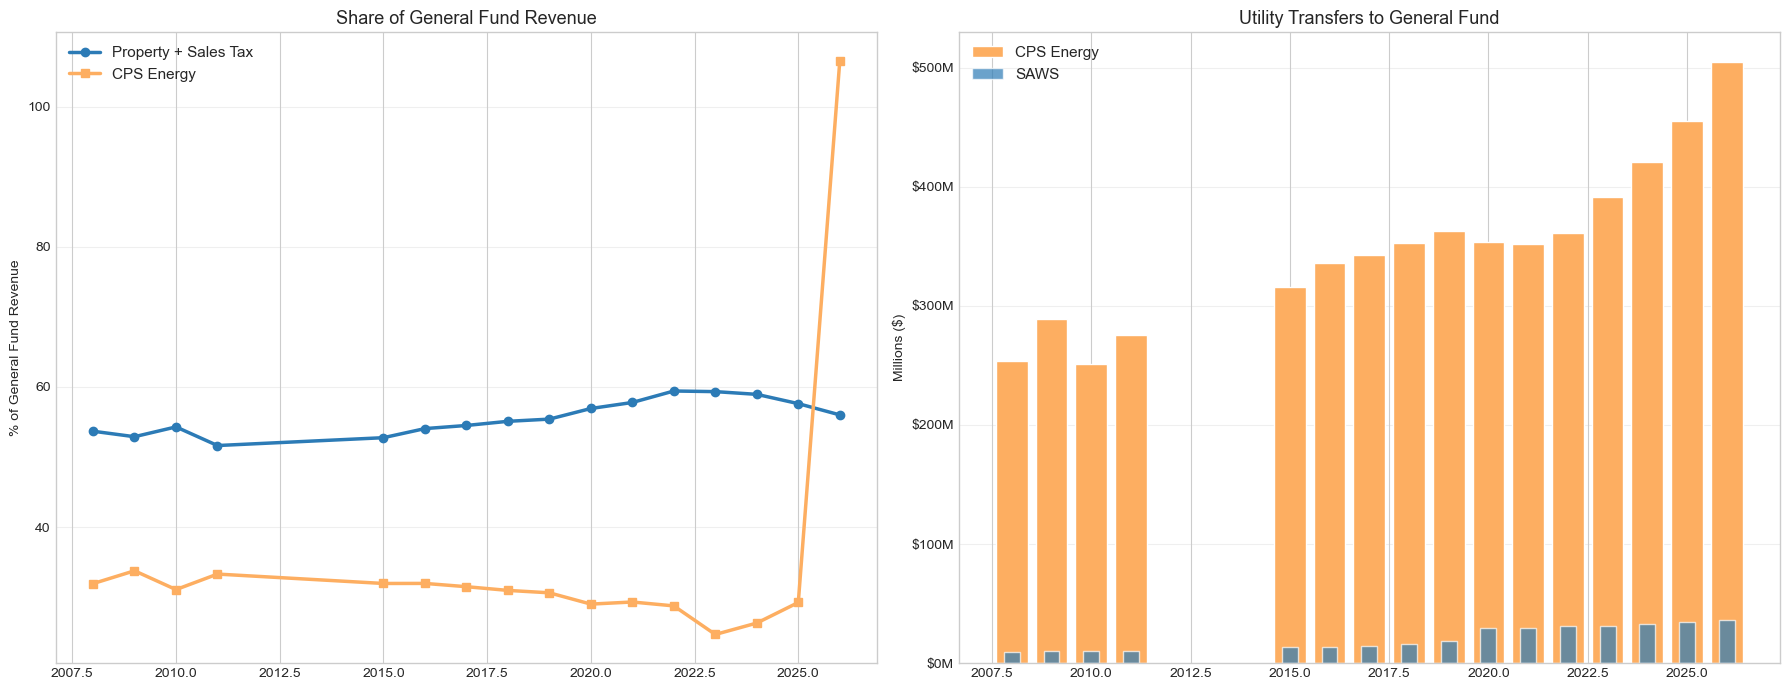

FY 2026 CPS Energy transfer: $504M (106.5% of GF revenue)
FY 2026 SAWS transfer:       $36M
Combined utility revenue:    $541M


In [11]:
# CPS Energy detail from the granular dataset
cps_detail = revenue[
    (revenue['fund'] == 'General Fund') &
    (revenue['line_item'].str.contains('CPS', case=False, na=False))
].copy()

cps_by_year = cps_detail.groupby('fiscal_year')['adopted_amount'].sum().sort_index()
tax_by_year = rev_pivot[['Property Tax', 'Sales Tax']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# CPS as share of General Fund
gf_total_by_year = rev_pivot.sum(axis=1)
cps_share = (cps_by_year / gf_total_by_year * 100).dropna()
tax_share = (tax_by_year / gf_total_by_year * 100).dropna()

axes[0].plot(tax_share.index, tax_share, 'o-', color='#2c7bb6', linewidth=2.5, label='Property + Sales Tax')
axes[0].plot(cps_share.index, cps_share, 's-', color='#fdae61', linewidth=2.5, label='CPS Energy')
axes[0].set_title('Share of General Fund Revenue', fontsize=13)
axes[0].set_ylabel('% of General Fund Revenue')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# CPS vs SAWS comparison
saws = rev_pivot.get('San Antonio Water System', pd.Series(dtype=float))
cps = rev_pivot.get('CPS Energy', pd.Series(dtype=float))

axes[1].bar(cps.dropna().index, cps.dropna() / 1e6, color='#fdae61', edgecolor='white', label='CPS Energy')
axes[1].bar(saws.dropna().index, saws.dropna() / 1e6, bottom=0, color='#2c7bb6',
            edgecolor='white', alpha=0.7, label='SAWS', width=0.4)
axes[1].set_title('Utility Transfers to General Fund', fontsize=13)
axes[1].set_ylabel('Millions ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'FY 2026 CPS Energy transfer: ${cps.iloc[-1]/1e6:,.0f}M ({cps_share.iloc[-1]:.1f}% of GF revenue)')
print(f'FY 2026 SAWS transfer:       ${saws.iloc[-1]/1e6:,.0f}M')
print(f'Combined utility revenue:    ${(cps.iloc[-1]+saws.iloc[-1])/1e6:,.0f}M')

## 9. How Revenue Becomes Spending — Fund Flow Overview

Putting it all together: revenue flows into fund types, which then get allocated to spending categories.
This is the full picture of how SA uses its money.

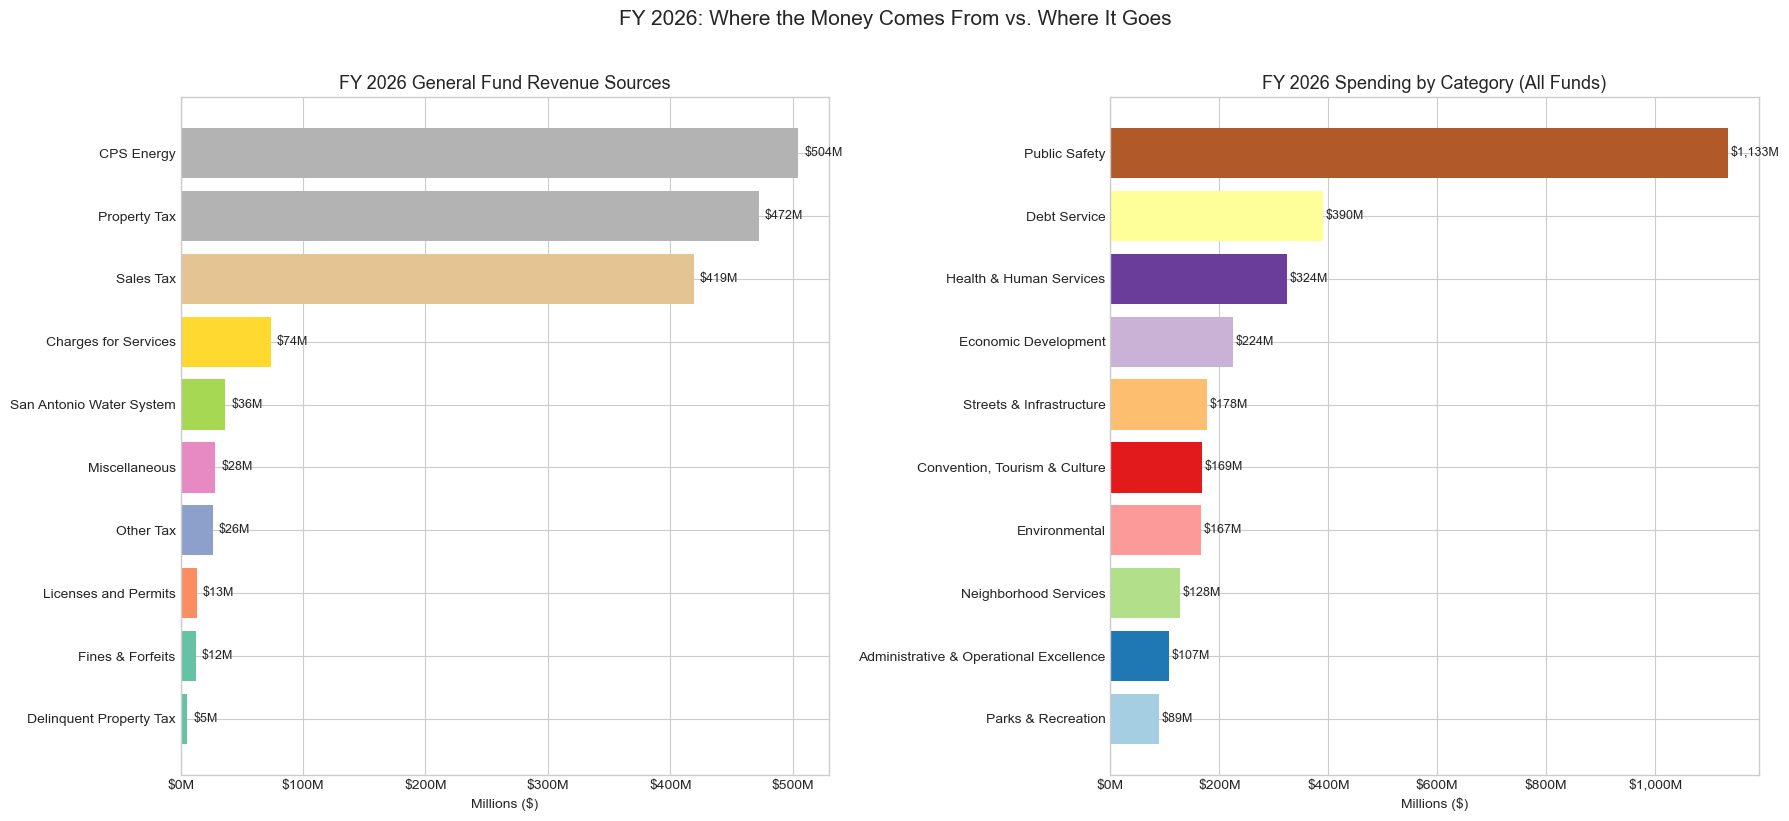

In [12]:
# Latest fiscal year comparison: revenue sources → spending categories
latest_fy = combined['fiscal_year'].max()

# Revenue side (General Fund breakdown)
gf_rev_latest = gf_rev[gf_rev['fiscal_year'] == latest_fy].set_index('line_item')['amount'].sort_values(ascending=True)
gf_rev_latest = gf_rev_latest[gf_rev_latest > 0]

# Spending side (All Funds categories)
spending = combined[
    (combined['fund'] == 'Total All Funds') &
    (combined['section'] == 'appropriation') &
    (combined['fiscal_year'] == latest_fy) &
    (~combined['line_item'].str.contains('Subtotal|TOTAL|Transfer|Reserve|GROSS|Financial|Amend|1 The', case=False, na=False))
].copy()
spending['line_item'] = spending['line_item'].replace({
    'Health and Human Services': 'Health & Human Services',
    'Parks and Recreation': 'Parks & Recreation',
    'Streets and Infrastructure': 'Streets & Infrastructure',
    'Economic Development & Development Svcs': 'Economic Development',
})
spend_latest = spending.set_index('line_item')['amount'].sort_values(ascending=True)
spend_latest = spend_latest[spend_latest > 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Revenue sources
bars1 = axes[0].barh(gf_rev_latest.index, gf_rev_latest / 1e6,
                     color=plt.cm.Set2(np.linspace(0, 1, len(gf_rev_latest))))
axes[0].set_xlabel('Millions ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].set_title(f'FY {latest_fy} General Fund Revenue Sources', fontsize=13)
for bar, val in zip(bars1, gf_rev_latest):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:,.0f}M', va='center', fontsize=9)

# Spending categories
bars2 = axes[1].barh(spend_latest.index, spend_latest / 1e6,
                     color=plt.cm.Paired(np.linspace(0, 1, len(spend_latest))))
axes[1].set_xlabel('Millions ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[1].set_title(f'FY {latest_fy} Spending by Category (All Funds)', fontsize=13)
for bar, val in zip(bars2, spend_latest):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:,.0f}M', va='center', fontsize=9)

plt.suptitle(f'FY {latest_fy}: Where the Money Comes From vs. Where It Goes', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 10. Long-Term Trends — What's Growing Fastest?

Which revenue sources and spending categories are growing faster than the city's overall budget?

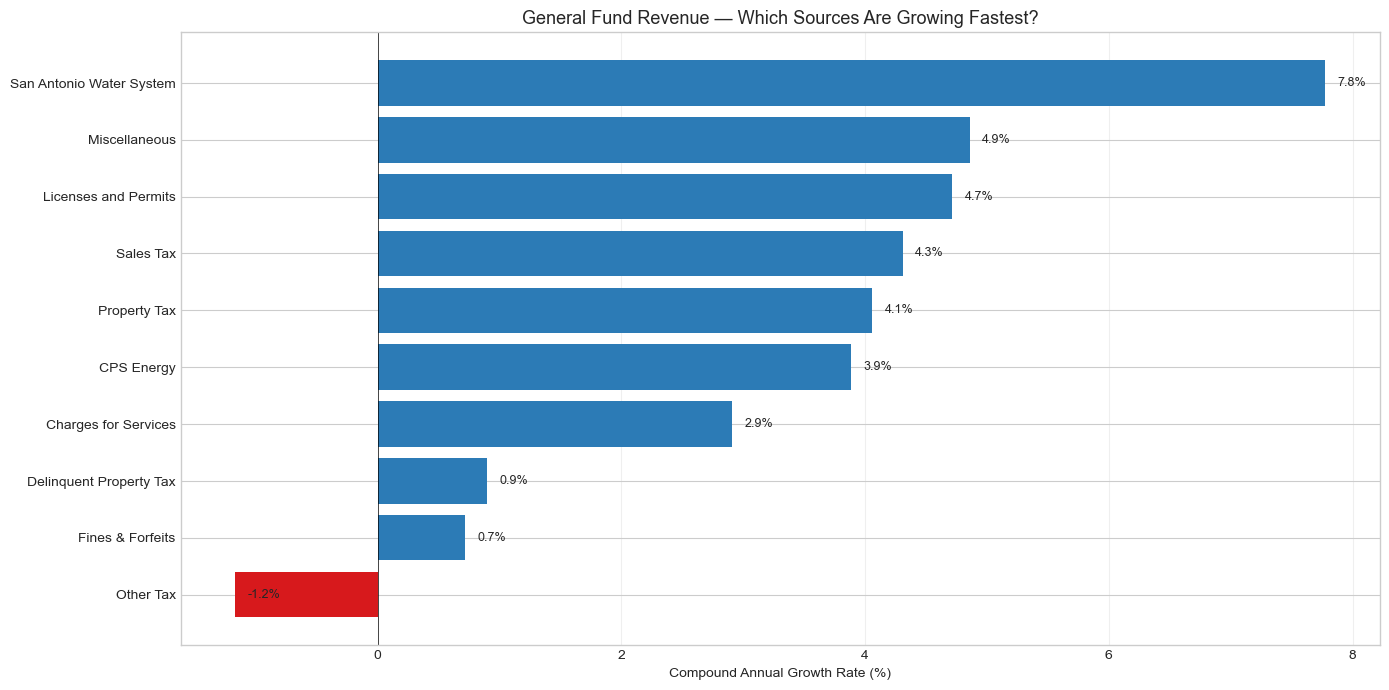


General Fund Revenue Growth Rates (CAGR):
  San Antonio Water System        +7.8%/yr  ($9M → $36M, FY2008–2026)
  Miscellaneous                   +4.9%/yr  ($12M → $28M, FY2008–2026)
  Licenses and Permits            +4.7%/yr  ($6M → $13M, FY2008–2026)
  Sales Tax                       +4.3%/yr  ($196M → $419M, FY2008–2026)
  Property Tax                    +4.1%/yr  ($231M → $472M, FY2008–2026)
  CPS Energy                      +3.9%/yr  ($254M → $504M, FY2008–2026)
  Charges for Services            +2.9%/yr  ($44M → $74M, FY2008–2026)
  Delinquent Property Tax         +0.9%/yr  ($5M → $5M, FY2011–2026)
  Fines & Forfeits                +0.7%/yr  ($11M → $12M, FY2008–2026)
  Other Tax                       -1.2%/yr  ($32M → $26M, FY2008–2026)


In [13]:
# Revenue CAGR (compound annual growth rate)
def cagr(first, last, years):
    if first <= 0 or last <= 0:
        return np.nan
    return (last / first) ** (1 / years) - 1

# Revenue growth
rev_growth = []
for col in rev_pivot.columns:
    data = rev_pivot[col].dropna()
    if len(data) >= 2 and data.iloc[0] > 0:
        n_years = data.index[-1] - data.index[0]
        rate = cagr(data.iloc[0], data.iloc[-1], n_years)
        rev_growth.append({
            'source': col,
            'first_fy': data.index[0],
            'first_val': data.iloc[0],
            'last_fy': data.index[-1],
            'last_val': data.iloc[-1],
            'cagr': rate
        })

rev_growth = pd.DataFrame(rev_growth).sort_values('cagr', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#d7191c' if x < 0 else '#2c7bb6' for x in rev_growth['cagr']]
ax.barh(rev_growth['source'], rev_growth['cagr'] * 100, color=colors)
ax.set_xlabel('Compound Annual Growth Rate (%)')
ax.set_title('General Fund Revenue — Which Sources Are Growing Fastest?', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

for i, row in rev_growth.iterrows():
    ax.text(row['cagr'] * 100 + 0.1, row['source'],
            f"{row['cagr']*100:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nGeneral Fund Revenue Growth Rates (CAGR):')
for _, row in rev_growth.sort_values('cagr', ascending=False).iterrows():
    print(f"  {row['source']:30s} {row['cagr']*100:+5.1f}%/yr  "
          f"(${row['first_val']/1e6:,.0f}M → ${row['last_val']/1e6:,.0f}M, FY{int(row['first_fy'])}–{int(row['last_fy'])})")

## Key Takeaways

1. **SA's total revenue has nearly doubled** from $1.7B (FY 2008) to $3.1B (FY 2026),
   driven by population growth, rising property values, and expanding enterprise operations.

2. **Three pillars fund the General Fund**: Property Tax, Sales Tax, and CPS Energy transfers
   together provide ~85% of General Fund revenue. CPS Energy alone contributes ~30% — a unique
   feature of SA's municipally-owned utility.

3. **Property tax is the fastest-growing pillar**, reflecting rising home values and annexation.
   Sales tax growth is strong but more volatile (it dipped during COVID in FY 2021).

4. **SA consistently budgets appropriations above revenue**, drawing on beginning balances
   and reserves. This is normal budgeting practice — the "deficit" is planned use of reserves,
   not structural overspending.

5. **Enterprise Funds are a growing share** of total revenue, especially airport operations
   ramping up for the new terminal project.

6. **Special Revenue Funds** include voter-mandated programs like Pre-K 4 SA and
   Tax Increment Financing districts — money that's earmarked and can't be redirected.